<a href="https://colab.research.google.com/github/hoor-05/Image-processing-labs/blob/main/Lab5_Spatial_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5 — Spatial Filtering: Smoothing and Sharpening



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

---


## Assessment Task 1 — 7×7 Box Filter

A **box filter** is the simplest smoothing filter: every pixel is replaced by the **average** of the pixels in a square window around it. Every weight is equal — like a blurred "box" of influence.

A 7×7 box kernel looks like:

$$K = \frac{1}{49}\begin{bmatrix} 1 & 1 & \cdots & 1 \\ 1 & 1 & \cdots & 1 \\ \vdots & & \ddots & \vdots \\ 1 & 1 & \cdots & 1 \end{bmatrix}$$

All 49 entries are `1/49` so the weights sum to 1 (preserves average brightness).

**Effect:** Blurs the image and reduces noise. Downside: also blurs edges and produces slightly "blocky" results because of the equal weights.

Steps:
1) Build the kernel manually.
2) Apply convolution. `cv2.filter2D` is the general-purpose convolution function. It takes any kernel you give it and slides it across the image.


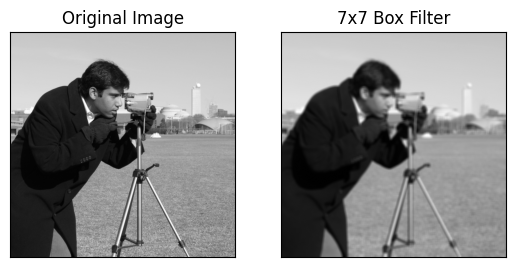

In [2]:
image = data.camera()

# 7x7 box filter
kernel = np.ones((7, 7), np.float32) / 49
box_filtered = cv2.filter2D(image, -1, kernel)

plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(box_filtered, cmap='gray')
plt.title('7x7 Box Filter'), plt.xticks([]), plt.yticks([])
plt.show()

## Assessment Task 2 — 5×5 and 21×21 Gaussian Filters

The **Gaussian filter** is a smarter blur than the box filter. Instead of giving all pixels equal weight, it weights **nearby pixels more** than far ones, following a 2D Gaussian (bell-curve) distribution:

$$G(x,y) = \frac{1}{2\pi\sigma^2}\, e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

A 5×5 Gaussian kernel (small blur):

$$\frac{1}{256}\begin{bmatrix}1 & 4 & 6 & 4 & 1\\4 & 16 & 24 & 16 & 4\\6 & 24 & 36 & 24 & 6\\4 & 16 & 24 & 16 & 4\\1 & 4 & 6 & 4 & 1\end{bmatrix}$$

**Why prefer Gaussian over box?**
- Smoother, more natural-looking blur (no blocky artifacts)
- Preserves edges slightly better for the same blur strength
- It's the mathematically optimal tradeoff between blurring and detail preservation

**Kernel size matters:**
- Small (e.g. 5×5) → gentle blur, subtle noise reduction
- Large (e.g. 21×21) → heavy blur, washes out fine detail

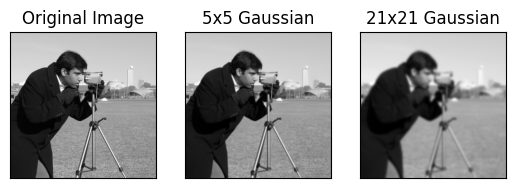

In [3]:
image = data.camera()

#Gaussian filters
gaussian_5 = cv2.GaussianBlur(image, (5, 5), 0)
gaussian_21 = cv2.GaussianBlur(image, (21, 21), 0)

plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(gaussian_5, cmap='gray')
plt.title('5x5 Gaussian'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(gaussian_21, cmap='gray')
plt.title('21x21 Gaussian'), plt.xticks([]), plt.yticks([])

plt.show()

## Assessment Task 3 — 3×3 Laplacian Sharpening

The **Laplacian** is a *second-order* derivative operator that responds to rapid intensity changes (edges) from any direction. A common 3×3 Laplacian kernel:

$$K = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

The Laplacian's raw output is **negative around bright edges and positive around dark ones**. By itself it doesn't look like an image — it looks like an edge map.

**Sharpening trick:**

$$\text{sharp} = \text{original} - \text{laplacian}$$

Subtracting the Laplacian from the original boosts edges. The result: the image looks the same, but edges pop more.

Steps (exactly as requested in the lab):
1. Read the image
2. Convert to `float32` (Laplacian can produce negatives)
3. Apply `cv2.Laplacian()`
4. Sharpen: `np.clip(image_float - laplacian, 0, 1)`
5. Plot the three images

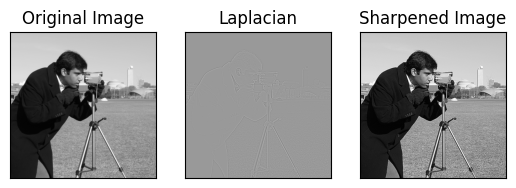

In [4]:
image = data.camera()

#make it float
image_float = image.astype(np.float32) / 255.0
#Laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F)
# Sharpen
sharpened = np.clip(image_float - laplacian, 0, 1)
plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(sharpened, cmap='gray')
plt.title('Sharpened Image'), plt.xticks([]), plt.yticks([])

plt.show()

## Q1 — Effect of Different Box Filter Sizes
Compare 3×3, 9×9, and 15×15 box filters. Bigger kernel = stronger blur = more detail lost.

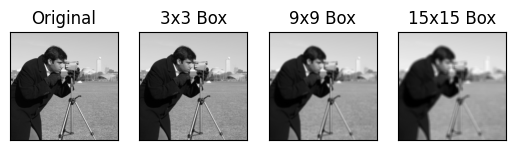

In [5]:
image = data.camera()

# box filters
box_3 = cv2.blur(image, (3, 3))
box_9 = cv2.blur(image, (9, 9))
box_15 = cv2.blur(image, (15, 15))

plt.subplot(141), plt.imshow(image, cmap='gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(142), plt.imshow(box_3, cmap='gray')
plt.title('3x3 Box'), plt.xticks([]), plt.yticks([])
plt.subplot(143), plt.imshow(box_9, cmap='gray')
plt.title('9x9 Box'), plt.xticks([]), plt.yticks([])
plt.subplot(144), plt.imshow(box_15, cmap='gray')
plt.title('15x15 Box'), plt.xticks([]), plt.yticks([])
plt.show()


## Q2 — Median Filter: Removing Salt-and-Pepper Noise
The **median filter** replaces each pixel with the *median* of its neighborhood — not the mean. It's the best tool for removing "salt and pepper" noise (random black and white specks), because the median ignores extreme outliers.

Compare the median filter to a Gaussian blur on the same noisy image — Gaussian smears the specks, median removes them cleanly.

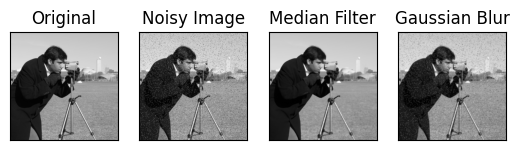

In [6]:
image = data.camera()

# Add salt and pepper noise
noisy = image.copy()
noise = np.random.choice([0, 255, -1], size=image.shape, p=[0.03, 0.03, 0.94])
noisy[noise == 0] = 0
noisy[noise == 255] = 255

#  filters
median = cv2.medianBlur(noisy, 5)
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)

plt.subplot(141), plt.imshow(image, cmap='gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(142), plt.imshow(noisy, cmap='gray')
plt.title('Noisy Image'), plt.xticks([]), plt.yticks([])
plt.subplot(143), plt.imshow(median, cmap='gray')
plt.title('Median Filter'), plt.xticks([]), plt.yticks([])
plt.subplot(144), plt.imshow(gaussian, cmap='gray')
plt.title('Gaussian Blur'), plt.xticks([]), plt.yticks([])
plt.show()

## Q3 — Bilateral Filter: Blurring While Keeping Edges Sharp
A normal Gaussian blur smooths everything — including edges. The **bilateral filter** is smarter: it blurs pixels only if they are close in *space* AND similar in *intensity*. Result: flat areas get smoothed, but edges stay crisp. Used in "beauty" filters, cartoon effects, and denoising.

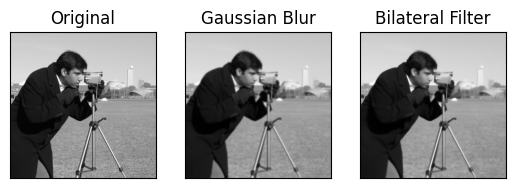

In [7]:
image = data.camera()

# Apply filters
gaussian = cv2.GaussianBlur(image, (9, 9), 0)
bilateral = cv2.bilateralFilter( image,9,75,75)

plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(gaussian, cmap='gray')
plt.title('Gaussian Blur'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(bilateral, cmap='gray')
plt.title('Bilateral Filter'), plt.xticks([]), plt.yticks([])
plt.show()